In [1]:
# import necessary libraries
import pandas as pd

In [2]:
# Load artificial dataset
df = pd.read_csv("data/binary_decision_tree_data.csv")
X = df.iloc[:, 0:9]
y = df.iloc[:, 10]

df.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,label
0,-1.530931,1.891626,1.047274,0.928932,-2.238880,1.898869,1.332551,2.078256,3.040864,-0.818434,0
1,-3.266254,1.747870,-0.803691,1.083145,1.210836,1.816399,-1.794192,2.846422,1.664636,0.498810,1
2,-1.058987,0.799849,2.027071,0.360442,-1.860209,1.749661,-0.755951,1.831933,2.957247,-1.324404,0
3,-1.850289,-2.546078,-1.114264,0.126459,-1.283923,7.471674,-0.915477,-3.684768,-0.312465,-4.420960,0
4,-0.775754,-1.228495,-0.472273,-0.660834,-2.428161,5.121593,1.446944,-1.611662,0.400561,-2.876528,0


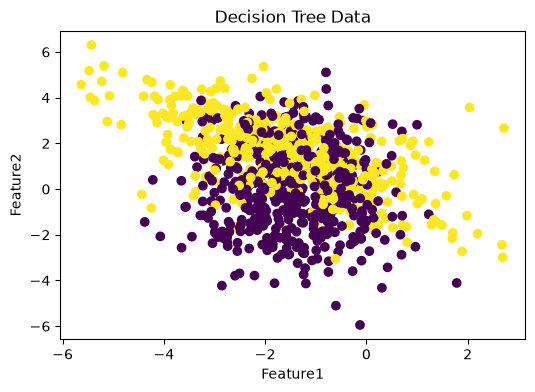

In [3]:
# Visualize the data (First two features)
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(X["x1"], X["x2"], c=y, cmap="viridis")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.title("Decision Tree Data")
plt.show()

In [4]:
# Split data into training and testing categories
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [5]:
# train Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [6]:
# Evaluate performance of model using test data
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

In [7]:
# import necessary libraries and print confusion matrix
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(y_test, y_pred))

[[102  11]
 [  5  82]]


In [12]:
# print classification report for evaluation metrics
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.90      0.93       113
           1       0.88      0.94      0.91        87

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200



In [9]:
# Print accuracy score
print(accuracy_score(y_test, y_pred))
print(accuracy_score(y_train, y_pred_train))

0.92
1.0
